In [116]:
import yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [117]:
with open("../config.yaml",'r') as file:
    config = yaml.safe_load(file)

In [136]:
config

{'data': {'raw': {'file1': '../data/raw/LeadScoring.csv',
   'file2': '../data/raw/Leads_Data_Dictionary.csv',
   'file3': '../data/raw/digital_marketing_campaign_dataset.csv',
   'file4': '../data/raw/bank.csv',
   'file5': '../data/raw/bank-full.csv',
   'file6': '../data/raw/bank-additional.csv',
   'file7': '../data/raw/bank-additional-full.csv',
   'file8': '../data/raw/marketing_campaign.csv'},
  'clean': {'file1': '../data/clean/leadscoring.csv',
   'file2': '../data/clean/bank-full.csv',
   'file3': '../data/clean/ready_to_model.csv',
   'file4': '../data/clean/ready_to_model_all_cols.csv',
   'file5': '../data/clean/marketing_campaign.csv'}}}

In [119]:
data = pd.read_csv(config['data']['clean']['file5'], quotechar='"', sep = ";")

In [120]:
data

,year_birth,education,marital_status,income,recency,wines,fruits,meat,fish,sweets,...,store,webvisits,complain,response,age,num_children,has_child,customer_tenure_in_days,total_spend,num_camp_success
0,1957,Postgraduate,Single,58138.0,58,635,88,546,172,88,...,4,7,0,1,57,0,False,665,1617,0
1,1954,Postgraduate,Single,46344.0,38,11,1,6,2,1,...,2,5,0,0,60,2,True,115,27,0
2,1965,Postgraduate,Partnered,71613.0,26,426,49,127,111,21,...,10,4,0,0,49,0,False,314,776,0
3,1984,Postgraduate,Partnered,26646.0,26,11,4,20,10,3,...,4,6,0,0,30,1,True,141,53,0
4,1981,PhD,Partnered,58293.0,94,173,43,118,46,27,...,6,5,0,0,33,1,True,163,422,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2210,1967,Postgraduate,Partnered,61223.0,46,709,43,182,42,118,...,4,5,0,0,47,1,True,383,1341,0
2211,1946,PhD,Partnered,64014.0,56,406,0,30,0,0,...,5,7,0,0,68,3,True,21,444,1
2212,1981,Postgraduate,Separated,56981.0,91,908,48,217,32,12,...,13,6,0,0,33,0,False,157,1241,1
2213,1956,Postgraduate,Partnered,69245.0,8,428,30,214,80,30,...,10,3,0,0,58,1,True,158,843,0


In [121]:
data.select_dtypes('number').corr()

,year_birth,income,recency,wines,fruits,meat,fish,sweets,gold,deals,...,catalogue,store,webvisits,complain,response,age,num_children,customer_tenure_in_days,total_spend,num_camp_success
year_birth,1.000000,-0.198064,-0.016023,-0.159225,-0.017653,-0.033499,-0.040265,-0.020013,-0.064030,-0.058953,...,-0.121610,-0.127660,0.123833,-0.030380,0.023825,-1.000000,-0.087429,0.020249,-0.113241,-0.002154
income,-0.198064,1.000000,0.006945,0.688269,0.507959,0.692465,0.520351,0.523746,0.389204,-0.108457,...,0.696541,0.630397,-0.650564,-0.030583,0.161049,0.198064,-0.344035,-0.024126,0.792650,0.366384
recency,-0.016023,0.006945,1.000000,0.015370,-0.005971,0.022254,0.000331,0.024859,0.017417,0.002470,...,0.023856,-0.000784,-0.018453,0.013599,-0.199981,0.016023,0.018322,0.026045,0.019706,-0.013829
wines,-0.159225,0.688269,0.015370,1.000000,0.386977,0.568752,0.397602,0.390178,0.392588,0.009235,...,0.634684,0.639889,-0.321928,-0.039516,0.246185,0.159225,-0.353782,0.168155,0.893098,0.510770
fruits,-0.017653,0.507959,-0.005971,0.386977,1.000000,0.547796,0.593407,0.571581,0.396443,-0.134416,...,0.486229,0.458457,-0.418706,-0.005338,0.122391,0.017653,-0.395900,0.067987,0.613249,0.157039
meat,-0.033499,0.692465,0.022254,0.568752,0.547796,1.000000,0.573507,0.535048,0.359328,-0.121079,...,0.734082,0.485877,-0.539464,-0.023814,0.237653,0.033499,-0.504574,0.089644,0.845853,0.307102
fish,-0.040265,0.520351,0.000331,0.397602,0.593407,0.573507,1.000000,0.583804,0.427056,-0.143062,...,0.532692,0.457641,-0.446392,-0.021246,0.108054,0.040265,-0.427852,0.081887,0.642311,0.176023
sweets,-0.020013,0.523746,0.024859,0.390178,0.571581,0.535048,0.583804,1.000000,0.357336,-0.121214,...,0.495054,0.455096,-0.422336,-0.022671,0.116065,0.020013,-0.389426,0.081048,0.606970,0.201386
gold,-0.064030,0.389204,0.017417,0.392588,0.396443,0.359328,0.427056,0.357336,1.000000,0.052161,...,0.442340,0.389039,-0.247638,-0.031163,0.140232,0.064030,-0.268922,0.160573,0.528599,0.196725
deals,-0.058953,-0.108457,0.002470,0.009235,-0.134416,-0.121079,-0.143062,-0.121214,0.052161,1.000000,...,-0.011897,0.066468,0.346003,0.000536,0.003617,0.058953,0.436123,0.218463,-0.065521,-0.125581


In [130]:
data.groupby('age')['response'].mean()

age
18     0.500000
19     0.200000
20     0.333333
21     0.400000
22     0.076923
23     0.266667
24     0.222222
25     0.034483
26     0.068966
27     0.222222
28     0.219512
29     0.125000
30     0.289474
31     0.268293
32     0.295455
33     0.131579
34     0.128205
35     0.113208
36     0.039474
37     0.215686
38     0.089888
39     0.132530
40     0.159420
41     0.152778
42     0.179487
43     0.162791
44     0.213333
45     0.142857
46     0.117647
47     0.136364
48     0.140000
49     0.081081
50     0.121951
51     0.136364
52     0.113636
53     0.228571
54     0.081633
55     0.120000
56     0.096154
57     0.195122
58     0.145455
59     0.166667
60     0.142857
61     0.200000
62     0.115385
63     0.023810
64     0.103448
65     0.366667
66     0.095238
67     0.250000
68     0.187500
69     0.250000
70     0.142857
71     0.333333
73     0.000000
74     0.000000
114    0.000000
115    0.000000
121    0.000000
Name: response, dtype: float64

In [134]:
data[data.age>100]
#not clear what the error was, as unlikely an undergraduate would be 14 and a PhD 15, so clearly not a simple 100 year mistake.

,year_birth,education,marital_status,income,recency,wines,fruits,meat,fish,sweets,...,store,webvisits,complain,response,age,num_children,has_child,customer_tenure_in_days,total_spend,num_camp_success


In [133]:
data= data[data.age<100]

In [155]:
data[['age', 'income']].corr()

,age,income
age,1.000000,0.199977
income,0.199977,1.000000


<Axes: xlabel='response', ylabel='income'>

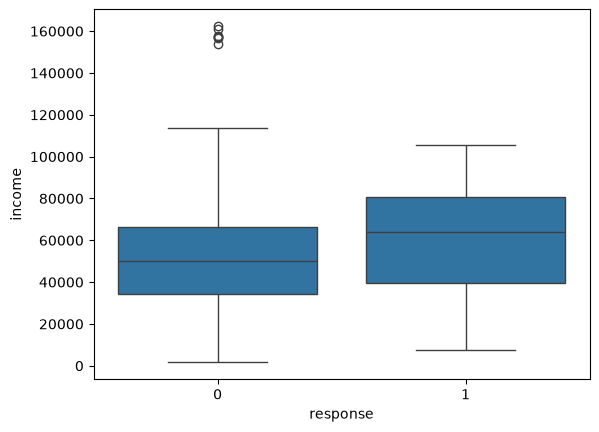

In [145]:
sns.boxplot(data=data,x='response', y='income')

In [159]:
from scipy.stats import ttest_ind
conv_success = data[data['response'] == 1].income
conv_failure = data[data['response'] == 0].income
t_stat, p_value = ttest_ind(conv_success, conv_failure, equal_var=False, alternative="two-sided") 
print(p_value)

3.828524702779496e-12


In [141]:
data.groupby('education')['response'].mean()

education
PhD              0.210417
Postgraduate     0.140541
Undergraduate    0.095238
Name: response, dtype: float64

In [146]:
from scipy.stats import chi2_contingency

table = pd.crosstab(data['education'], data['response'])
chi2, p, dof, expected = chi2_contingency(table)

print(p)

3.2948152369671924e-05


In [157]:
data.groupby('marital_status')['response'].mean()

marital_status
Partnered    0.110644
Separated    0.214984
Single       0.228512
Name: response, dtype: float64

In [156]:
table = pd.crosstab(data['marital_status'], data['response'])
chi2, p, dof, expected = chi2_contingency(table)

print(p)

1.1251116734354296e-11


In [149]:
data.groupby('complain')['response'].mean()

complain
0    0.150547
1    0.150000
Name: response, dtype: float64

In [151]:
data.groupby('num_children')['response'].mean()

num_children
0    0.265823
1    0.104129
2    0.112981
3    0.040000
Name: response, dtype: float64

In [160]:
conv_success = data[data['response'] == 1].num_children
conv_failure = data[data['response'] == 0].num_children
t_stat, p_value = ttest_ind(conv_success, conv_failure, equal_var=False, alternative="two-sided") 
print(p_value)

1.0477521170075279e-14


In [161]:
conv_success = data[data['response'] == 1].has_child
conv_failure = data[data['response'] == 0].has_child
t_stat, p_value = ttest_ind(conv_success, conv_failure, equal_var=False, alternative="two-sided") 
print(p_value)

2.9167361996062935e-17


In [143]:
data.groupby('num_camp_success')['response'].mean()

num_camp_success
0    0.083238
1    0.310559
2    0.518519
3    0.795455
4    0.909091
Name: response, dtype: float64

In [162]:
conv_success = data[data['response'] == 1].num_camp_success
conv_failure = data[data['response'] == 0].num_camp_success
t_stat, p_value = ttest_ind(conv_success, conv_failure, equal_var=False, alternative="two-sided") 
print(p_value)

7.503991317819388e-32


In [122]:
data.columns

Index(['year_birth', 'education', 'marital_status', 'income', 'recency',
       'wines', 'fruits', 'meat', 'fish', 'sweets', 'gold', 'deals', 'web',
       'catalogue', 'store', 'webvisits', 'complain', 'response', 'age',
       'num_children', 'has_child', 'customer_tenure_in_days', 'total_spend',
       'num_camp_success'],
      dtype='str')

In [158]:
data.to_csv("../data/clean/CP_ready_to_model.csv", index=False, encoding= "utf-8", sep = ";")

Age and income are not correlated. Campaigns were more success for higher incomes, higher levels of education and those that live alone and have no children. People are more likely to respond positively if they have previously.